In [26]:
!pip install pyotp mplfinance pandas_ta fyers_apiv3 pygame stable-baselines3 gymnasium

In [27]:
import requests
import base64
from datetime import datetime, timedelta, date
from datetime import time as dt_time
import time
import threading
import pyotp
from pytz import timezone
import pandas as pd
import numpy as np
from urllib.parse import urlparse, parse_qs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import mplfinance as mpf
import pandas_ta as ta
import pygame
import os
import pytz
import json
import re
import random

import gymnasium as gym

from IPython.display import display, clear_output

from fyers_apiv3 import fyersModel
from fyers_apiv3.FyersWebsocket import data_ws

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout, Attention, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback, ModelCheckpoint
from scipy.signal import argrelextrema
import tensorflow as tf
from scipy.signal import find_peaks

In [28]:
def get_index_symbol_and_quantity(index):

    # Dictionary mapping index name to index symbols
    index_symbols = {
        'Bankex': 'BSE:BANKEX-INDEX',
        'Finnifty': 'NSE:FINNIFTY-INDEX',
        'Bank Nifty': 'NSE:NIFTYBANK-INDEX',
        'Nifty': 'NSE:NIFTY50-INDEX',
        'Sensex': 'BSE:SENSEX-INDEX'
    }

    # Determine the index symbol for the given index
    index_symbol = index_symbols.get(index, 'Invalid Index')

    # Determine the quantity based on the index symbol
    if index_symbol == "NSE:NIFTY50-INDEX":
        quantity = 25  # 25 is one lot for Nifty
    elif index_symbol == "NSE:NIFTYBANK-INDEX":
        quantity = 15  # 15 is one lot for Bank Nifty
    elif index_symbol == "NSE:FINNIFTY-INDEX":
        quantity = 40  # 40 is one lot for Finnifty
    elif index_symbol == "BSE:SENSEX-INDEX":
        quantity = 20  # 20 is two lot for Sensex
    elif index_symbol == "BSE:BANKEX-INDEX":
        quantity = 15  # 15 is one lot for Bankex
    else:
        quantity = 0  # Default value if none of the conditions match

    return index_symbol, quantity

In [29]:
app_id = "TS79V3NXK1-100"
secret_key = "KQCPB0FJ74"
redirect_uri = "https://google.com"
fyers_user = "XM22383"
fyers_pin = "4628"
fyers_totp = "EAQD6K4IUYOEGPJNVE6BMPTUSDCWIOHW"
response_type = "code"
state = "sample_state"
grant_type = "authorization_code"

fyers = None
fyers_socket = None

index_symbol, quantity = get_index_symbol_and_quantity("Bank Nifty")

interval_minutes = 5 # Set the interval to 1, 5, or 15 minutes

ist_timezone = pytz.timezone("Asia/Kolkata")

#Variables
ce_ltp = 0
pe_ltp = 0
index_ltp = 0
buy_sell_checked = False
ce_strike = None
pe_strike = None
ce_symbol = None
pe_symbol = None

target = 80
trailing_sl = 40

brokerage = 100

fixed_ltp = 0
fixed_index_ltp = 0
prev_ltp = 0
target_inside = 0
target_index_inside = 0
trailing_sl_inside = 0
trailing_index_inside = 0

active_order = False

sl_hit_condition = False
total_loss = 0
total_profit = 0
overall_win = 0
overall_loss = 0
total_points = 0

unsubscribe_done = False

active_order_sleep = 1

In [30]:
session = fyersModel.SessionModel(
    client_id=app_id,
    secret_key=secret_key,
    redirect_uri=redirect_uri,
    response_type=response_type,
    grant_type=grant_type
)

def getEncodedString(string):
    string = str(string)
    base64_bytes = base64.b64encode(string.encode("ascii"))
    return base64_bytes.decode("ascii")

if session is not None:
    session.generate_authcode()

    url_send_login_otp = "https://api-t2.fyers.in/vagator/v2/send_login_otp_v2"
    res = requests.post(url=url_send_login_otp, json={"fy_id": getEncodedString(fyers_user), "app_id": "2"}).json()

    if datetime.now().second % 30 > 27:
        time.sleep(5)

    url_verify_otp = "https://api-t2.fyers.in/vagator/v2/verify_otp"
    res2 = requests.post(url=url_verify_otp, json={"request_key": res["request_key"], "otp": pyotp.TOTP(fyers_totp).now()}).json()

    ses = requests.Session()
    url_verify_otp2 = "https://api-t2.fyers.in/vagator/v2/verify_pin_v2"
    payload2 = {"request_key": res2["request_key"], "identity_type": "pin", "identifier": getEncodedString(fyers_pin)}
    res3 = ses.post(url=url_verify_otp2, json=payload2).json()

    ses.headers.update({'authorization': f"Bearer {res3['data']['access_token']}"})

    tokenurl = "https://api-t1.fyers.in/api/v3/token"
    payload3 = {
        "fyers_id": fyers_user,
        "app_id": app_id[:-4],
        "redirect_uri": redirect_uri,
        "appType": "100",
        "code_challenge": "",
        "state": "None",
        "scope": "",
        "nonce": "",
        "response_type": "code",
        "create_cookie": True
    }

    res3 = ses.post(url=tokenurl, json=payload3).json()

    url = res3['Url']
    parsed = urlparse(url)
    auth_code = parse_qs(parsed.query)['auth_code'][0]

    session.set_token(auth_code)

    auth_response = session.generate_token()
    access_token = auth_response["access_token"]

    fyers = fyersModel.FyersModel(client_id=app_id, token=access_token)

    ws_token = app_id + ":" + access_token
    fyers_socket = data_ws.FyersDataSocket(access_token=ws_token, log_path="")

pd.DataFrame(fyers.get_profile())

,s,code,message,data
fy_id,ok,200,,XM22383
name,ok,200,,MARSHAL TUDU
image,ok,200,,https://myaccount-docs-prod.fyers.in/Profile_P...
display_name,ok,200,,None
pin_change_date,ok,200,,25-09-2023 17:16:16
email_id,ok,200,,iammarshal22@gmail.com
pwd_change_date,ok,200,,01-06-2022 20:36:31
PAN,ok,200,,---------
mobile_number,ok,200,,8458060663
totp,ok,200,,True


In [31]:
def fetch_candle_data(number):
    while True:
        try:
            today = date.today()
            yesterday = today - timedelta(number)

            data = {
                "symbol": index_symbol,
                "resolution": interval_minutes,
                "date_format": "1",
                "range_from": yesterday,
                "range_to": today,
                "cont_flag": "1"
            }

            result = fyers.history(data=data)

            if result is not None:
                return result
        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [32]:
def fetch_train_candle_data(days_count):
    train_df = pd.DataFrame()

    while True:
        try:
            date_increment = 100
            for i in range(days_count):
                today = date.today() - timedelta(date_increment)
                yesterday = today - timedelta(100)

                data = {
                    "symbol": index_symbol,
                    "resolution": interval_minutes,
                    "date_format": "1",
                    "range_from": yesterday,
                    "range_to": today,
                    "cont_flag": "1"
                }

                result = fyers.history(data=data)

                if result is not None:
                    temp_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                    train_df = pd.concat([temp_df, train_df], ignore_index=True)

                date_increment += 100

            if train_df is not None:
                return train_df

        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [33]:
train_candles = fetch_candle_data(100)
train_df = pd.DataFrame(train_candles['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])

#train_df = fetch_train_candle_data(25)

print(len(train_df))

train_df = train_df.drop_duplicates(subset='datetime', keep='first')

print(len(train_df))

5112
5112


In [77]:
class DataProcessor:
    def __init__(self, train_df, peak_length=14, indicator_length=14):
        """
        Initialize the DataProcessor with separate lengths for peak detection and indicators.
        :param train_df: Input DataFrame with OHLC data.
        :param peak_length: Length used for peak detection (support/resistance).
        :param indicator_length: Length used for technical indicators.
        """
        self.train_df = train_df.copy()
        self.peak_length = peak_length  # Length for support and resistance peaks
        self.indicator_length = indicator_length  # Length for indicators like RSI, EMA, ATR

    def preprocess_datetime(self):
        """
        Preprocess the datetime column: convert to IST and handle duplicates or missing values.
        """
        ist = timezone('Asia/Kolkata')
        self.train_df['datetime'] = pd.to_datetime(self.train_df['datetime'], unit='s')
        self.train_df['datetime'] = (
            self.train_df['datetime']
            .dt.tz_localize('UTC')
            .dt.tz_convert(ist)
            .dt.tz_localize(None)
        )

        if self.train_df['datetime'].duplicated().any() or self.train_df['datetime'].isnull().any():
            raise ValueError("The 'datetime' column contains duplicates or missing values.")

        self.train_df.set_index(self.train_df['datetime'], inplace=True)
        self.train_df.drop(['datetime'], axis=1, inplace=True, errors='ignore')
        return self

    def clean_data(self):
        """
        Handle volume column and remove rows with missing or zero values.
        """
        if 'volume' in self.train_df.columns:
            self.train_df['volume'] = self.train_df['volume'].fillna(0)
            if (self.train_df['volume'] == 0).all() or self.train_df['volume'].isnull().all():
                self.train_df.drop(['volume'], axis=1, inplace=True, errors='ignore')
        self.train_df.dropna(inplace=True)
        return self

    def add_indicators(self):
        """
        Add technical indicators dynamically based on the provided indicator length.
        """
        # Add RSI, EMA, ATR dynamically using the indicator_length
        self.train_df['rsi'] = ta.rsi(self.train_df['close'], length=self.indicator_length)
        self.train_df['ema'] = ta.ema(self.train_df['close'], length=self.indicator_length)
        self.train_df['atr'] = ta.atr(self.train_df['high'], self.train_df['low'], self.train_df['close'], length=self.indicator_length)

        # Bollinger Bands with dynamic length
        bbands = ta.bbands(self.train_df['close'], length=self.indicator_length)
        self.train_df['bb_upper'] = bbands['BBU_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_middle'] = bbands['BBM_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_lower'] = bbands['BBL_' + str(self.indicator_length) + '_2.0']

        # Target and Stop Loss based on ATR
        self.train_df['Target'] = self.train_df['atr'] * 2
        self.train_df['Stop Loss'] = self.train_df['atr']
        return self

    def calculate_support_resistance(self):
        """
        Calculate support and resistance levels using peaks detection with separate peak_length.
        """
        # Resistance (local maxima)
        resistance_peaks, _ = find_peaks(self.train_df['high'], distance=self.peak_length)
        self.train_df['resistance'] = 0.0
        self.train_df.loc[self.train_df.index[resistance_peaks], 'resistance'] = self.train_df['high'].iloc[resistance_peaks]

        # Support (local minima)
        support_peaks, _ = find_peaks(-self.train_df['low'], distance=self.peak_length)
        self.train_df['support'] = 0.0
        self.train_df.loc[self.train_df.index[support_peaks], 'support'] = self.train_df['low'].iloc[support_peaks]

        return self

    def process(self):
        """
        Chain all preprocessing steps together.
        """
        return (
            self.preprocess_datetime()
            .clean_data()
            .add_indicators()
            .calculate_support_resistance()
        )

In [78]:
# 1. Data Preprocessing
data_processor = DataProcessor(train_df, peak_length=50, indicator_length=14)
processed_df = data_processor.process().train_df

processed_df

,open,high,low,close,rsi,ema,atr,bb_upper,bb_middle,bb_lower,Target,Stop Loss,resistance,support
datetime,,,,,,,,,,,,,,
2024-09-12 09:15:00,51271.00,51271.00,51125.75,51228.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.0
2024-09-12 09:20:00,51229.75,51250.05,51201.50,51244.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.0
2024-09-12 09:25:00,51246.00,51307.05,51246.00,51287.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51307.05,0.0
2024-09-12 09:30:00,51285.65,51304.50,51198.20,51229.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.0
2024-09-12 09:35:00,51230.25,51238.05,51146.40,51148.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20 15:05:00,50773.90,50773.90,50711.50,50740.30,31.098193,50843.699069,86.561542,51039.283938,50848.350000,50657.416062,173.123084,86.561542,0.00,0.0
2024-12-20 15:10:00,50745.05,50770.15,50688.25,50688.35,28.420713,50822.985860,86.228575,51014.253591,50826.196429,50638.139266,172.457149,86.228575,0.00,0.0
2024-12-20 15:15:00,50690.95,50770.10,50686.85,50735.95,34.025668,50811.381079,86.015819,50995.639747,50812.150000,50628.660253,172.031639,86.015819,0.00,0.0


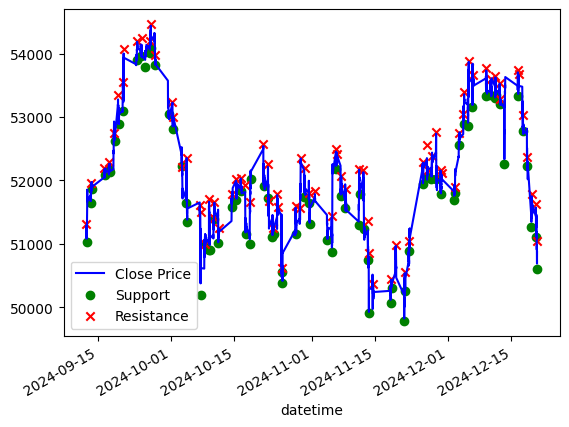

In [64]:
# Visualize the results
processed_df['close'].plot(label='Close Price', color='blue')
plt.scatter(processed_df.index, processed_df['support'], label='Support', color='green', marker='o')
plt.scatter(processed_df.index, processed_df['resistance'], label='Resistance', color='red', marker='x')
plt.legend()
plt.show()

In [66]:
class SignalGenerationAgent:
    def __init__(self, train_df):
        self.train_df = train_df.copy()
        self.scaler = MinMaxScaler()

    def label_signals(self):
        """
        Generate buy/sell signals based on target and stop-loss levels.
        """
        self.train_df['Signal'] = 0  # Hold Signal
        self.train_df['Entry Price'] = 0.0
        self.train_df['Exit Price'] = 0.0

        for i in range(len(self.train_df)):
            entry_price = self.train_df['close'].iloc[i]
            target = self.train_df['Target'].iloc[i]
            stop_loss = self.train_df['Stop Loss'].iloc[i]

            buy_target_price = entry_price + target
            buy_sl_price = entry_price - stop_loss
            sell_target_price = entry_price - target
            sell_sl_price = entry_price + stop_loss

            future_data = self.train_df.iloc[i + 1:]

            # Buy Signal
            for j in range(len(future_data)):
                future_high = future_data['high'].iloc[j]
                future_low = future_data['low'].iloc[j]

                if future_high >= buy_target_price:
                    self.train_df.at[self.train_df.index[i], 'Signal'] = 1  # Buy Signal
                    self.train_df.at[self.train_df.index[i], 'Entry Price'] = entry_price
                    self.train_df.at[self.train_df.index[i], 'Exit Price'] = future_high
                    break
                elif future_low <= buy_sl_price:
                    break

            # Sell Signal
            for j in range(len(future_data)):
                future_high = future_data['high'].iloc[j]
                future_low = future_data['low'].iloc[j]

                if future_low <= sell_target_price:
                    self.train_df.at[self.train_df.index[i], 'Signal'] = 2  # Sell Signal
                    self.train_df.at[self.train_df.index[i], 'Entry Price'] = entry_price
                    self.train_df.at[self.train_df.index[i], 'Exit Price'] = future_low
                    break
                elif future_high >= sell_sl_price:
                    break

        self.train_df.drop(columns=['Entry Price', 'Exit Price'], inplace=True)

        return self.train_df

    def scale_data(self):
        """
        Scale all numeric columns in the DataFrame.
        """
        numeric_cols = self.train_df.select_dtypes(include=[np.number]).columns
        self.train_df[numeric_cols] = self.scaler.fit_transform(self.train_df[numeric_cols])
        return self.train_df

    def final_labelled_signals(self):
        """
        Finalize the labelled signals and scale the data.
        """
        self.train_df = self.label_signals()
        #self.train_df = self.scale_data()
        return self.train_df



# 2. Signal Generation
signal_agent = SignalGenerationAgent(processed_df)
final_train_df = signal_agent.final_labelled_signals()

final_train_df

,open,high,low,close,rsi,ema,atr,bb_upper,bb_middle,bb_lower,Target,Stop Loss,resistance,support,Signal
datetime,,,,,,,,,,,,,,,
2024-09-12 09:15:00,51271.00,51271.00,51125.75,51228.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2024-09-12 09:20:00,51229.75,51250.05,51201.50,51244.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2024-09-12 09:25:00,51246.00,51307.05,51246.00,51287.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51307.05,NaN,0
2024-09-12 09:30:00,51285.65,51304.50,51198.20,51229.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2024-09-12 09:35:00,51230.25,51238.05,51146.40,51148.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20 15:05:00,50773.90,50773.90,50711.50,50740.30,31.098193,50843.699069,86.561542,51039.283938,50848.350000,50657.416062,173.123084,86.561542,NaN,NaN,1
2024-12-20 15:10:00,50745.05,50770.15,50688.25,50688.35,28.420713,50822.985860,86.228575,51014.253591,50826.196429,50638.139266,172.457149,86.228575,NaN,NaN,1
2024-12-20 15:15:00,50690.95,50770.10,50686.85,50735.95,34.025668,50811.381079,86.015819,50995.639747,50812.150000,50628.660253,172.031639,86.015819,NaN,NaN,1


In [37]:


class MarketAnalysisAgent:
    def __init__(self, train_df):
        self.train_df = train_df.copy()

    def preprocess_data(self):
        ist = timezone('Asia/Kolkata')

        self.train_df['datetime'] = pd.to_datetime(self.train_df['datetime'], unit='s')
        self.train_df['datetime'] = (
            self.train_df['datetime']
            .dt.tz_localize('UTC')
            .dt.tz_convert(ist)
            .dt.tz_localize(None)
        )

        if self.train_df['datetime'].duplicated().any() or self.train_df['datetime'].isnull().any():
            raise ValueError("The 'datetime' column contains duplicates or missing values.")

        self.train_df.set_index(self.train_df['datetime'], inplace=True)
        if (self.train_df['volume'] == 0).all() or self.train_df['volume'].isnull().all():
            self.train_df.drop(['volume'], axis=1, inplace=True, errors='ignore')
        self.train_df.drop(['datetime'], axis=1, inplace=True, errors='ignore')

        # Adding new columns (hour_of_day, day_of_week, etc.)
        self.train_df['hour_of_day'] = self.train_df.index.hour
        self.train_df['day_of_week'] = self.train_df.index.dayofweek

        self.train_df['high_low_range'] = self.train_df['high'] - self.train_df['low']
        self.train_df['open_close_range'] = self.train_df['open'] - self.train_df['close']

        lengths = [14]

        # Calculate technical indicators (EMA, RSI, ATR, etc.)
        for length in lengths:
            self.train_df[f'EMA_{length}'] = ta.ema(self.train_df['close'], length=length)
            self.train_df[f'RSI_{length}'] = ta.rsi(self.train_df['close'], length=length)
            self.train_df[f'ATR_{length}'] = ta.atr(
                self.train_df['high'], self.train_df['low'], self.train_df['close'], length=length
            )

        # Define target and stop loss using ATR
        self.train_df['Target'] = self.train_df['ATR_14'] * 2
        self.train_df['Stop Loss'] = self.train_df['ATR_14']

        # Round the values and remove any remaining NaN values
        self.train_df = self.train_df.round(2)
        self.train_df.dropna(inplace=True)

        return self.train_df

    def analyze(self):
        # Preprocess and analyze the data
        self.preprocess_data()
        return self.train_df

test_market_analysis_agent = MarketAnalysisAgent(train_df).analyze()
test_market_analysis_agent

,open,high,low,close,hour_of_day,day_of_week,high_low_range,open_close_range,EMA_14,RSI_14,ATR_14,Target,Stop Loss
datetime,,,,,,,,,,,,,
2024-09-12 10:25:00,51149.80,51175.95,51128.40,51147.65,10,3,47.55,2.15,51193.10,41.89,68.38,136.76,68.38
2024-09-12 10:30:00,51147.10,51167.20,51099.15,51155.85,10,3,68.05,-8.75,51188.13,43.33,68.34,136.69,68.34
2024-09-12 10:35:00,51154.65,51210.40,51147.90,51207.80,10,3,62.50,-53.15,51190.75,51.51,67.74,135.48,67.74
2024-09-12 10:40:00,51206.60,51208.45,51130.15,51139.95,10,3,78.30,66.65,51183.98,42.81,68.79,137.59,68.79
2024-09-12 10:45:00,51140.55,51155.70,51111.00,51113.70,10,3,44.70,26.85,51174.61,40.00,66.46,132.92,66.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20 15:05:00,50773.90,50773.90,50711.50,50740.30,15,4,62.40,33.60,50843.70,31.10,86.56,173.12,86.56
2024-12-20 15:10:00,50745.05,50770.15,50688.25,50688.35,15,4,81.90,56.70,50822.99,28.42,86.23,172.46,86.23
2024-12-20 15:15:00,50690.95,50770.10,50686.85,50735.95,15,4,83.25,-45.00,50811.38,34.03,86.02,172.03,86.02


In [38]:
class SignalGenerationAgent:
    def __init__(self, train_df):
        self.train_df = train_df.copy()

    def label_signals(self):
        # Initialize the 'Signal' column with default values
        self.train_df['Signal'] = 0 # Hold Signal
        self.train_df['Entry Price'] = 0.0
        self.train_df['Exit Price'] = 0.0

        for i in range(len(self.train_df)):
            entry_price = self.train_df['close'].iloc[i]
            target = self.train_df['Target'].iloc[i]
            stop_loss = self.train_df['Stop Loss'].iloc[i]

            buy_target_price = entry_price + target
            buy_sl_price = entry_price - stop_loss
            sell_target_price = entry_price - target
            sell_sl_price = entry_price + stop_loss

            future_data = self.train_df.iloc[i + 1:]

            for j in range(len(future_data)):
                future_high = future_data['high'].iloc[j]
                future_low = future_data['low'].iloc[j]

                if future_high >= buy_target_price:
                    self.train_df.at[self.train_df.index[i], 'Signal'] = 1 # Buy Signal
                    self.train_df.at[self.train_df.index[i], 'Entry Price'] = entry_price
                    self.train_df.at[self.train_df.index[i], 'Exit Price'] = future_high
                    break
                elif future_low <= buy_sl_price:
                    break

            for j in range(len(future_data)):
                future_high = future_data['high'].iloc[j]
                future_low = future_data['low'].iloc[j]

                if future_low <= sell_target_price:
                    self.train_df.at[self.train_df.index[i], 'Signal'] = 2 # Sell Signal
                    self.train_df.at[self.train_df.index[i], 'Entry Price'] = entry_price
                    self.train_df.at[self.train_df.index[i], 'Exit Price'] = future_low
                    break
                elif future_high >= sell_sl_price:
                    break

        return self.train_df

    def final_labelled_signals(self):
        # Remove the 'Entry Price' and 'Exit Price' columns
        self.train_df = self.label_signals()
        self.train_df = self.train_df.drop(columns=['Entry Price', 'Exit Price'])
        return self.train_df

test_signal_generation_agent = SignalGenerationAgent(test_market_analysis_agent).label_signals()
test_signal_generation_agent

,open,high,low,close,hour_of_day,day_of_week,high_low_range,open_close_range,EMA_14,RSI_14,ATR_14,Target,Stop Loss,Signal,Entry Price,Exit Price
datetime,,,,,,,,,,,,,,,,
2024-09-12 10:25:00,51149.80,51175.95,51128.40,51147.65,10,3,47.55,2.15,51193.10,41.89,68.38,136.76,68.38,0,0.00,0.00
2024-09-12 10:30:00,51147.10,51167.20,51099.15,51155.85,10,3,68.05,-8.75,51188.13,43.33,68.34,136.69,68.34,0,0.00,0.00
2024-09-12 10:35:00,51154.65,51210.40,51147.90,51207.80,10,3,62.50,-53.15,51190.75,51.51,67.74,135.48,67.74,2,51207.80,51025.00
2024-09-12 10:40:00,51206.60,51208.45,51130.15,51139.95,10,3,78.30,66.65,51183.98,42.81,68.79,137.59,68.79,0,0.00,0.00
2024-09-12 10:45:00,51140.55,51155.70,51111.00,51113.70,10,3,44.70,26.85,51174.61,40.00,66.46,132.92,66.46,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20 15:05:00,50773.90,50773.90,50711.50,50740.30,15,4,62.40,33.60,50843.70,31.10,86.56,173.12,86.56,1,50740.30,50915.35
2024-12-20 15:10:00,50745.05,50770.15,50688.25,50688.35,15,4,81.90,56.70,50822.99,28.42,86.23,172.46,86.23,1,50688.35,50915.35
2024-12-20 15:15:00,50690.95,50770.10,50686.85,50735.95,15,4,83.25,-45.00,50811.38,34.03,86.02,172.03,86.02,1,50735.95,50915.35


In [39]:
class RiskManagementAgent:
    def __init__(self):
        self.position_active = False
        self.entry_price = None
        self.position_type = None  # "long" or "short"
        self.total_reward = 0  # To track cumulative percentage rewards

    def manage_position(self, action, current_price, target, stop_loss, signal):
        reward = 0
        exit_position = False
        hit_target = False  # Used for accuracy calculation

        if self.position_active:
            # Calculate the target and stop loss based on the position type
            if self.position_type == "long":
                target_price = self.entry_price + target
                stop_loss_price = self.entry_price - stop_loss
            elif self.position_type == "short":
                target_price = self.entry_price - target
                stop_loss_price = self.entry_price + stop_loss

            # Check if the target or stop loss is hit
            if self.position_type == "long":
                if current_price >= target_price:  # Target hit for long
                    reward = (current_price - self.entry_price) / self.entry_price
                    exit_position = True
                    hit_target = True
                elif current_price <= stop_loss_price:  # Stop Loss hit
                    reward = (current_price - self.entry_price) / self.entry_price
                    exit_position = True

            elif self.position_type == "short":
                if current_price <= target_price:  # Target hit for short
                    reward = (self.entry_price - current_price) / self.entry_price
                    exit_position = True
                    hit_target = True
                elif current_price >= stop_loss_price:  # Stop Loss hit
                    reward = (self.entry_price - current_price) / self.entry_price
                    exit_position = True

            # Exit position after target or stop loss is hit
            if exit_position:
                # Adjust reward based on signal match
                if (self.position_type == "long" and signal == 1) or (self.position_type == "short" and signal == 2):
                    reward *= 5  # Double the reward for correct signal match

                # Update total cumulative reward
                self.total_reward += reward

                # Store the trade details in train_trade_history
                train_trade_history.append({
                    'position_type': self.position_type,
                    'entry_price': self.entry_price,
                    'exit_price': current_price,
                    'target_price': target_price,
                    'stop_loss_price': stop_loss_price,
                    'reward': reward,
                    'hit_target': hit_target,
                    'total_reward': self.total_reward
                })

                # Reset position
                self.position_active = False
                self.entry_price = None
                self.position_type = None

        else:
            # Open a new position based on the action
            if action == 1:  # Buy (long)
                self.position_active = True
                self.entry_price = current_price
                self.position_type = "long"

            elif action == 2:  # Sell (short)
                self.position_active = True
                self.entry_price = current_price
                self.position_type = "short"

        # Double the reward if the action matches the signal (new position scenario)
        if not self.position_active and signal is not None:
            if (action == 1 and signal == 1) or (action == 2 and signal == 2):
                reward *= 5

        return reward, self.position_active, hit_target


In [40]:
class MetaRLAgent:
    def __init__(self, learning_rate=0.01, discount_factor=0.99, exploration_rate=1.0):
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate
        self.exploration_decay = 0.995
        self.min_exploration_rate = 0.01
        self.q_table = {}  # Q-table for state-action values

    def _state_to_key(self, state):
        """Converts the state into a hashable key for Q-table."""
        return tuple(np.round(state, decimals=3))

    def act(self, state):
        state_key = self._state_to_key(state)
        # Exploration vs Exploitation
        if random.random() < self.exploration_rate:
            return random.choice([0, 1, 2])  # Random action
        return np.argmax(self.q_table.get(state_key, [0, 0, 0]))  # Best action

    def learn(self, state, action, reward, next_state, done):
        state_key = self._state_to_key(state)
        next_state_key = self._state_to_key(next_state)

        # Initialize Q-values for unseen states
        if state_key not in self.q_table:
            self.q_table[state_key] = [0, 0, 0]
        if next_state_key not in self.q_table:
            self.q_table[next_state_key] = [0, 0, 0]

        # Q-Learning update
        q_value = self.q_table[state_key][action]
        max_next_q = max(self.q_table[next_state_key])
        td_target = reward + self.discount_factor * max_next_q * (not done)
        td_error = td_target - q_value
        self.q_table[state_key][action] += self.learning_rate * td_error

        # Decay exploration rate
        self.exploration_rate = max(
            self.min_exploration_rate, self.exploration_rate * self.exploration_decay
        )

    def save_model(self, filename):
        """Saves the Q-table as a CSV."""
        q_table_df = pd.DataFrame.from_dict(self.q_table, orient="index")
        q_table_df.to_csv(filename)

    def load_model(self, filename):
        """Loads the Q-table from a CSV."""
        q_table_df = pd.read_csv(filename, index_col=0)
        self.q_table = q_table_df.to_dict(orient="index")

In [41]:
class TradingEnvironment(gym.Env):
    def __init__(self, data_df, live=False, memory_length=25, sequence_length=5):
        super().__init__()
        self.df = data_df.copy()
        self.live = live
        self.memory_length = memory_length
        self.sequence_length = sequence_length
        self.current_step = 0
        self.risk_agent = RiskManagementAgent()
        self.profit_trades = 0
        self.loss_trades = 0
        self.total_trades = 0
        self.sequence = []
        self.memory = []

        # Update observation space to include sequence and memory
        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.df.shape[1] * self.sequence_length + self.memory_length,),
        )
        self.action_space = gym.spaces.Discrete(3)  # 0: Hold, 1: Buy, 2: Sell

    def reset(self):
        self.current_step = 0
        self.risk_agent = RiskManagementAgent()
        self.memory = []
        self.sequence = []
        self.profit_trades = 0
        self.loss_trades = 0
        self.total_trades = 0


        self.state = self.df.iloc[self.current_step].values
        self.sequence.append(self.state)

        # Pad initial sequence with zeros if insufficient data
        padded_sequence = np.zeros((self.sequence_length, self.df.shape[1]))
        padded_sequence[-len(self.sequence):] = self.sequence

        memory_features = np.zeros(self.memory_length)
        return np.concatenate([padded_sequence.flatten(), memory_features])

    def step(self, action):
        reward = 0
        self.current_step += 1

        if self.current_step >= len(self.df):
            done = True
            next_state = np.zeros_like(self.state)
        else:
            done = False
            current_data = self.df.iloc[self.current_step]
            current_price = current_data["close"]
            target = current_data["Target"]
            stop_loss = current_data["Stop Loss"]
            signal = current_data.get("Signal", None)

            reward, position_active, hit_target = self.risk_agent.manage_position(
                action, current_price, target, stop_loss, signal
            )

            if hit_target or reward < 0:
                self.total_trades += 1
                if reward > 0:
                    self.profit_trades += 1
                else:
                    self.loss_trades += 1

            next_state = current_data.values
            self.sequence.append(next_state)

            if len(self.sequence) > self.sequence_length:
                self.sequence.pop(0)

            # Memory features
            memory_features = (
                np.mean(self.memory, axis=0) if self.memory else np.zeros(self.memory_length)
            )

            self.memory.append(self.state)
            if len(self.memory) > self.memory_length:
                self.memory.pop(0)

            # Flatten the sequence and append memory features
            sequence_data = np.array(self.sequence)
            next_state = np.concatenate([sequence_data.flatten(), memory_features])

        info = {
            "position_active": self.risk_agent.position_active,
            "profit_trades": self.profit_trades,
            "loss_trades": self.loss_trades,
            "accuracy": (self.profit_trades / self.total_trades * 100) if self.total_trades > 0 else 0,
        }
        return next_state, reward, done, info

In [42]:
def train_agent(train_df, episodes=100):
    # Step 1: Analyze and enrich the training data
    market_analysis_agent = MarketAnalysisAgent(train_df)
    enriched_train_df = market_analysis_agent.analyze()

    signal_generation_agent = SignalGenerationAgent(enriched_train_df)
    enriched_train_df = signal_generation_agent.final_labelled_signals()

    # Step 2: Initialize the trading environment and agent
    env = TradingEnvironment(enriched_train_df)
    meta_agent = MetaRLAgent()

    # Step 3: Train the agent
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0

        while True:
            action = meta_agent.act(state)
            next_state, reward, done, info = env.step(action)
            meta_agent.learn(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            if done:
                break

        # Log episode progress
        print(f"Episode {episode + 1} Total Reward: {total_reward}")
        print(f"Accuracy: {info['accuracy']:.2f}%")

    # Step 4: Save the trained model
    meta_agent.save_model("meta_agent_model.csv")
    return meta_agent



train_agent(train_df)

NameError: name 'train_trade_history' is not defined

In [ ]:
pd.DataFrame(train_trade_history).tail(20)

In [ ]:
def live_agent(real_df):
    market_analysis_agent = MarketAnalysisAgent(real_df)
    enriched_real_df = market_analysis_agent.analyze()
    enriched_real_df = enriched_real_df[-1:]

    env = TradingEnvironment(enriched_real_df, live=True)
    meta_agent = MetaRLAgent()
    meta_agent.load_model("meta_agent_model.csv")

    state = env.reset()
    total_reward = 0

    while True:
        action = meta_agent.act(state)
        next_state, reward, done, info = env.step(action)
        meta_agent.learn(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        print(f"Action: {['HOLD', 'BUY', 'SELL'][action]}, Reward: {reward}, Total Reward: {total_reward}")

        if done:  # Reset environment at the end of the data
            print("End of live data stream")
            break

live_agent(train_df)